
Processing: Respiratory infections and tuberculosis
d=0 | ADF p=0.5182, KPSS p=0.0100
d=1 | ADF p=0.0000, KPSS p=0.1000
Selected d: 1


C:\Users\kumar\AppData\Local\Temp\ipykernel_23096\2504521075.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(temp, regression='c', nlags="auto")[1]
C:\Users\kumar\AppData\Local\Temp\ipykernel_23096\2504521075.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(temp, regression='c', nlags="auto")[1]
C:\Users\kumar\anaconda3\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\kumar\anaconda3\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dat

Best model: (2, 1, 0)

Ljung-Box Test:
     lb_stat  lb_pvalue
10  0.500233   0.999993


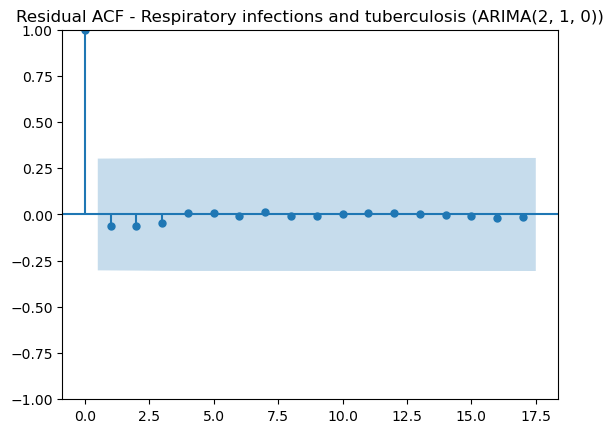

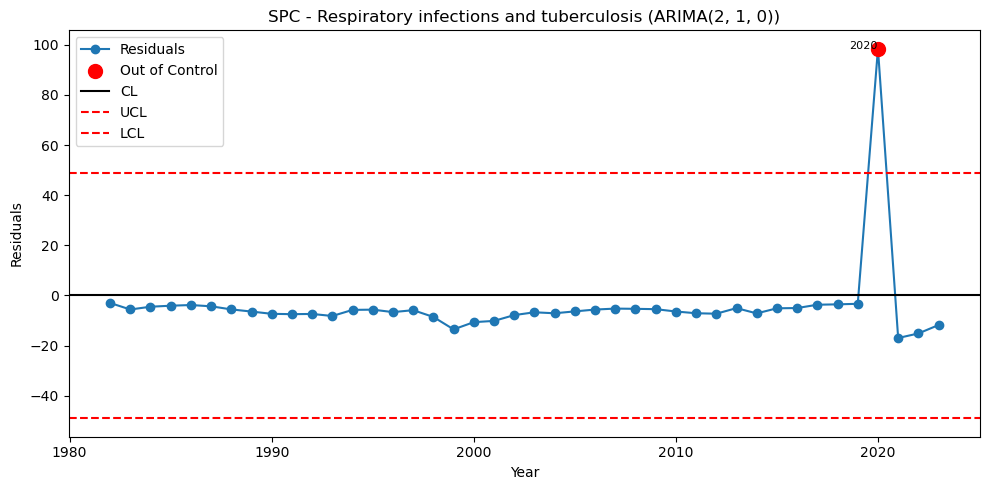


Processing: Cardiovascular diseases
d=0 | ADF p=0.9934, KPSS p=0.0100
d=1 | ADF p=0.0763, KPSS p=0.1000
d=2 | ADF p=0.0373, KPSS p=0.0417
Selected d: 2


C:\Users\kumar\AppData\Local\Temp\ipykernel_23096\2504521075.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(temp, regression='c', nlags="auto")[1]
C:\Users\kumar\AppData\Local\Temp\ipykernel_23096\2504521075.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(temp, regression='c', nlags="auto")[1]
C:\Users\kumar\anaconda3\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\kumar\anaconda3\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dat

Best model: (0, 2, 1)

Ljung-Box Test:
     lb_stat  lb_pvalue
10  9.716601   0.465699


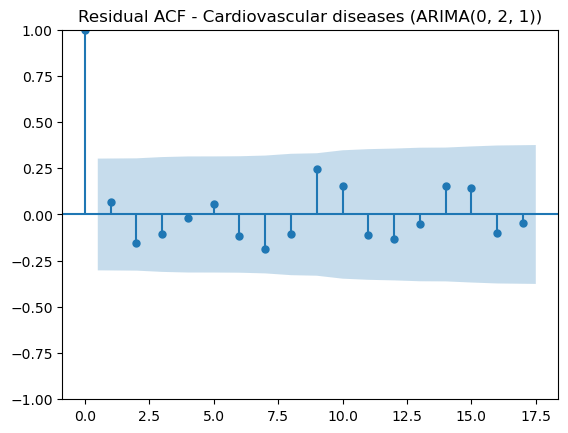

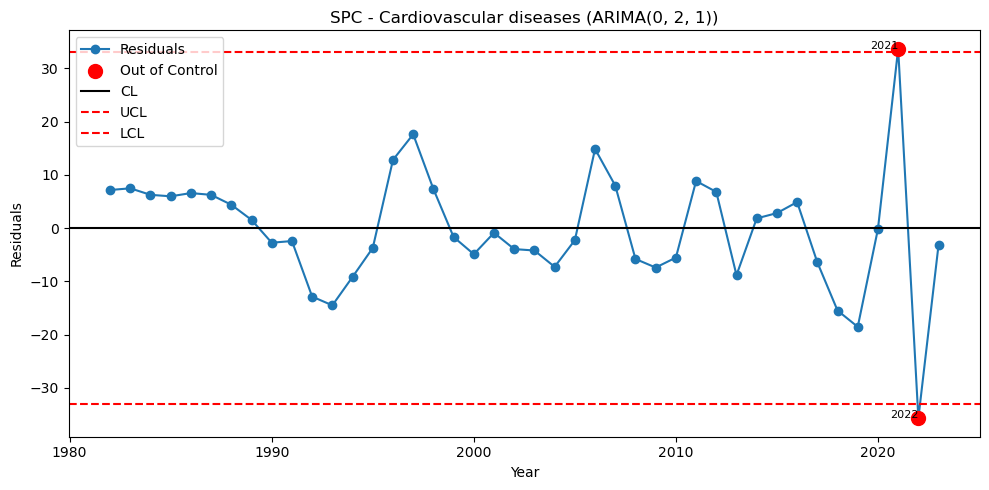


Processing: Enteric infections
d=0 | ADF p=0.6662, KPSS p=0.0100
d=1 | ADF p=0.3045, KPSS p=0.0943
d=2 | ADF p=0.0000, KPSS p=0.1000
Selected d: 2


C:\Users\kumar\AppData\Local\Temp\ipykernel_23096\2504521075.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(temp, regression='c', nlags="auto")[1]
C:\Users\kumar\AppData\Local\Temp\ipykernel_23096\2504521075.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(temp, regression='c', nlags="auto")[1]
C:\Users\kumar\anaconda3\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\kumar\anaconda3\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dat

Best model: (2, 2, 2)

Ljung-Box Test:
    lb_stat  lb_pvalue
10  6.66238   0.756887


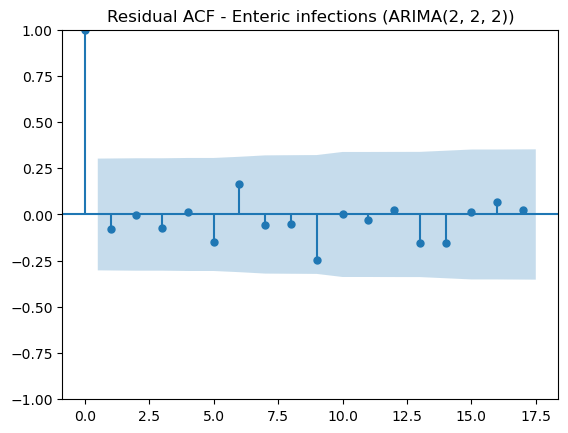

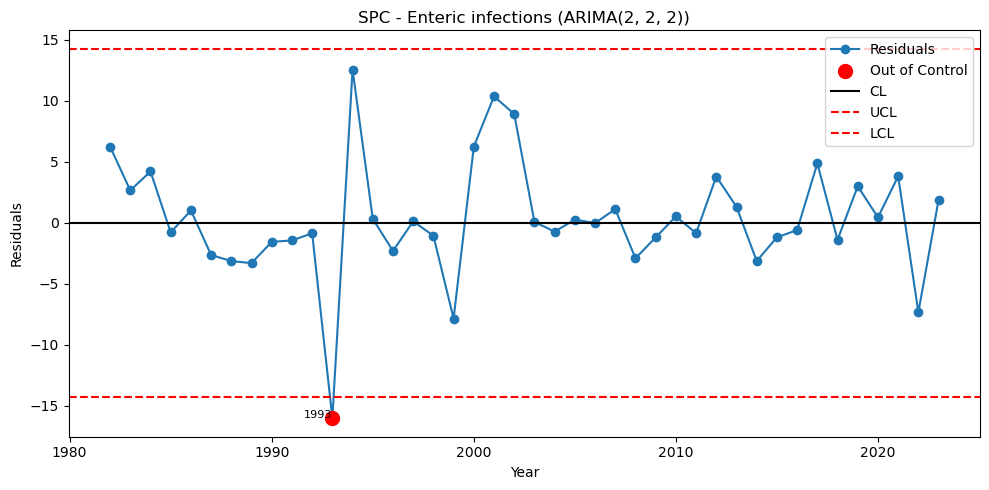

In [2]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
def find_d(ts, max_d=2):
    temp = ts.copy()
    
    for d in range(max_d + 1):
        
        adf_p = adfuller(temp)[1]
        kpss_p = kpss(temp, regression='c', nlags="auto")[1]
        
        print(f"d={d} | ADF p={adf_p:.4f}, KPSS p={kpss_p:.4f}")
        
        # Stationary condition
        if adf_p < 0.05 and kpss_p > 0.05:
            return d
        
        # Only difference if not at max_d
        if d < max_d:
            temp = temp.diff().dropna()
    
    return max_d



df = pd.read_csv("C:/Users/kumar/Downloads/both_gender.csv")
df = df[df['location_name'] == 'Andhra Pradesh']

diseases = [
    'Respiratory infections and tuberculosis',
    'Cardiovascular diseases',	
    'Enteric infections'
]

for disease in diseases:
    
    print("\n" + "="*60)
    print(f"Processing: {disease}")
    
    df_d = df[df['cause_name'] == disease].sort_values('year')
    ts = df_d['val']
    ts.index = df_d['year']
    
    d = find_d(ts)
    print("Selected d:", d)
    
    best_aic = np.inf
    best_model = None
    
    for p, q in itertools.product(range(3), range(3)):
        try:
            model = ARIMA(ts, order=(p, d, q)).fit()
            if model.aic < best_aic:
                best_aic = model.aic
                best_model = model
                best_order = (p, d, q)
        except:
            continue
    
    print("Best model:", best_order)
    
    residuals = best_model.resid.iloc[2:]
    
    print("\nLjung-Box Test:")
    print(acorr_ljungbox(residuals, lags=[10], return_df=True))
    
    plot_acf(residuals)
    plt.title(f"Residual ACF - {disease} (ARIMA{best_order})")
    plt.show()
    
    mean = 0
    std = np.std(residuals)
    
    ucl = mean + 3*std
    lcl = mean - 3*std
    
    out_of_control = (residuals > ucl) | (residuals < lcl)
    
    plt.figure(figsize=(10,5))
    
    plt.plot(residuals.index, residuals, marker='o', label='Residuals')
    
    plt.scatter(residuals.index[out_of_control],
                residuals[out_of_control],
                color='red',
                s=100,
                label='Out of Control',
                zorder=3)
    
    plt.axhline(mean, color='black', label='CL')
    plt.axhline(ucl, linestyle='--', color='red', label='UCL')
    plt.axhline(lcl, linestyle='--', color='red', label='LCL')
    
    for x, y in zip(residuals.index[out_of_control], residuals[out_of_control]):
        plt.text(x, y, str(x), fontsize=8, ha='right')
    
    plt.xlabel("Year")
    plt.ylabel("Residuals")
    plt.title(f"SPC - {disease} (ARIMA{best_order})")
    
    plt.legend()
    plt.tight_layout()
    plt.show()


Processing: Respiratory infections and tuberculosis
d=0 | ADF p=0.5182, KPSS p=0.0100
d=1 | ADF p=0.0000, KPSS p=0.1000
Selected d: 1


C:\Users\kumar\AppData\Local\Temp\ipykernel_23096\1279136672.py:21: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(temp, regression='c', nlags="auto")[1]
C:\Users\kumar\AppData\Local\Temp\ipykernel_23096\1279136672.py:21: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(temp, regression='c', nlags="auto")[1]
C:\Users\kumar\anaconda3\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\kumar\anaconda3\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dat

Best model: (2, 1, 0)

Ljung-Box Test:
     lb_stat  lb_pvalue
10  0.500233   0.999993


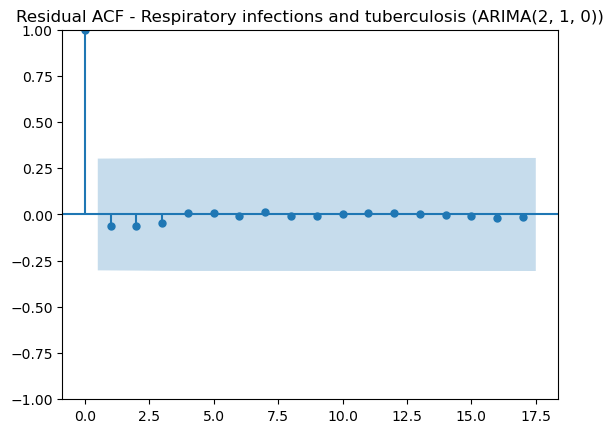

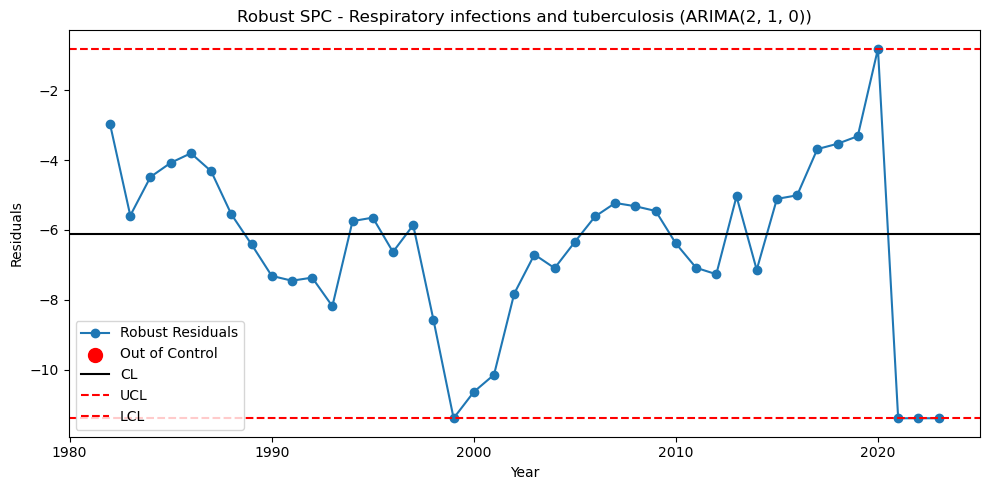


Processing: Cardiovascular diseases
d=0 | ADF p=0.9934, KPSS p=0.0100
d=1 | ADF p=0.0763, KPSS p=0.1000
d=2 | ADF p=0.0373, KPSS p=0.0417
Selected d: 2


C:\Users\kumar\AppData\Local\Temp\ipykernel_23096\1279136672.py:21: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(temp, regression='c', nlags="auto")[1]
C:\Users\kumar\AppData\Local\Temp\ipykernel_23096\1279136672.py:21: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(temp, regression='c', nlags="auto")[1]
C:\Users\kumar\anaconda3\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\kumar\anaconda3\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dat

Best model: (0, 2, 1)

Ljung-Box Test:
     lb_stat  lb_pvalue
10  9.716601   0.465699


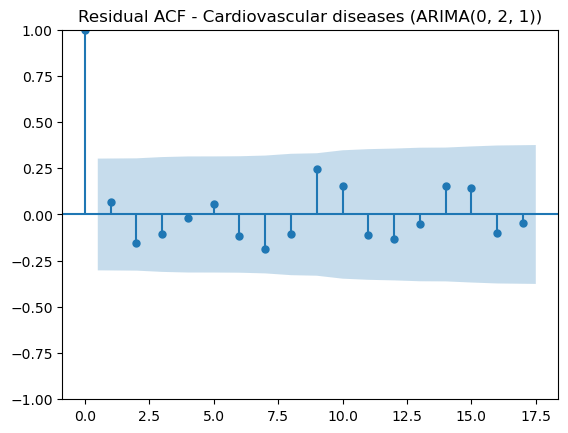

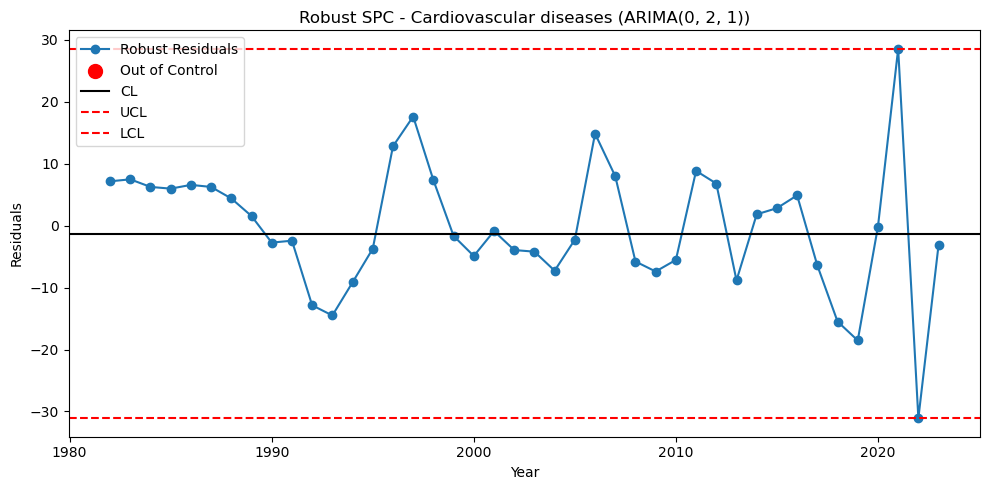


Processing: Enteric infections
d=0 | ADF p=0.6662, KPSS p=0.0100
d=1 | ADF p=0.3045, KPSS p=0.0943
d=2 | ADF p=0.0000, KPSS p=0.1000
Selected d: 2


C:\Users\kumar\AppData\Local\Temp\ipykernel_23096\1279136672.py:21: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(temp, regression='c', nlags="auto")[1]
C:\Users\kumar\AppData\Local\Temp\ipykernel_23096\1279136672.py:21: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(temp, regression='c', nlags="auto")[1]
C:\Users\kumar\anaconda3\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\kumar\anaconda3\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dat

Best model: (2, 2, 2)

Ljung-Box Test:
    lb_stat  lb_pvalue
10  6.66238   0.756887


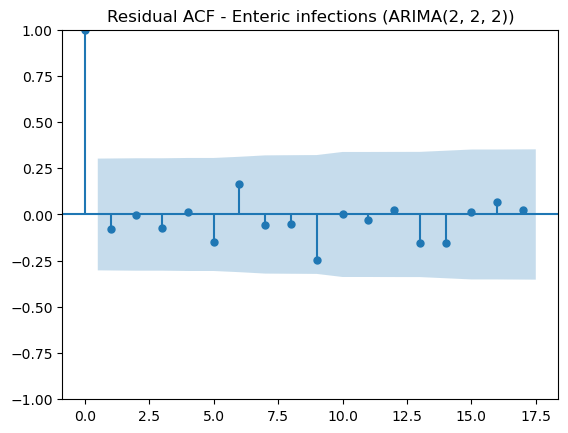

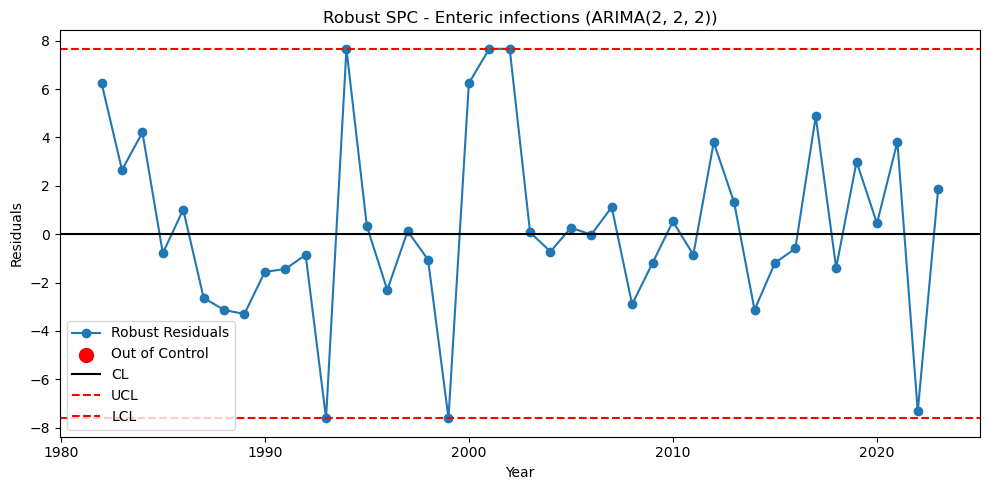

In [1]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf


# -------------------------------
# STEP 1: Find differencing order
# -------------------------------
def find_d(ts, max_d=2):
    temp = ts.copy()
    
    for d in range(max_d + 1):
        
        adf_p = adfuller(temp)[1]
        kpss_p = kpss(temp, regression='c', nlags="auto")[1]
        
        print(f"d={d} | ADF p={adf_p:.4f}, KPSS p={kpss_p:.4f}")
        
        if adf_p < 0.05 and kpss_p > 0.05:
            return d
        
        if d < max_d:
            temp = temp.diff().dropna()
    
    return max_d


# -------------------------------
# STEP 2: IRFFT-like robust filter
# -------------------------------
def robust_residuals_irfft_like(residuals, max_iter=5, c=3.0):
    
    r = residuals.copy()
    
    for _ in range(max_iter):
        
        median = np.median(r)
        mad = np.median(np.abs(r - median))
        
        if mad == 0:
            break
        
        sigma = 1.4826 * mad
        
        z = (r - median) / sigma
        
        # downweight outliers
        weights = np.where(np.abs(z) <= c, 1, c / np.abs(z))
        
        r = median + weights * (r - median)
    
    return r


# -------------------------------
# STEP 3: Load data
# -------------------------------
df = pd.read_csv("C:/Users/kumar/Downloads/both_gender.csv")
df = df[df['location_name'] == 'Andhra Pradesh']

diseases = [
    'Respiratory infections and tuberculosis',
    'Cardiovascular diseases',	
    'Enteric infections'
]


# -------------------------------
# STEP 4: Main Loop
# -------------------------------
for disease in diseases:
    
    print("\n" + "="*60)
    print(f"Processing: {disease}")
    
    df_d = df[df['cause_name'] == disease].sort_values('year')
    ts = df_d['val']
    ts.index = df_d['year']
    
    # Find differencing
    d = find_d(ts)
    print("Selected d:", d)
    
    # -------------------------------
    # Model selection
    # -------------------------------
    best_aic = np.inf
    best_model = None
    
    for p, q in itertools.product(range(3), range(3)):
        try:
            model = ARIMA(ts, order=(p, d, q)).fit()
            if model.aic < best_aic:
                best_aic = model.aic
                best_model = model
                best_order = (p, d, q)
        except:
            continue
    
    print("Best model:", best_order)
    
    # -------------------------------
    # Residuals (RAW)
    # -------------------------------
    residuals_raw = best_model.resid.iloc[2:]
    
    print("\nLjung-Box Test:")
    print(acorr_ljungbox(residuals_raw, lags=[10], return_df=True))
    
    plot_acf(residuals_raw)
    plt.title(f"Residual ACF - {disease} (ARIMA{best_order})")
    plt.show()
    
    # -------------------------------
    # APPLY IRFFT-LIKE ROBUST FILTER
    # -------------------------------
    residuals = robust_residuals_irfft_like(residuals_raw)
    
    # -------------------------------
    # ROBUST CONTROL LIMITS
    # -------------------------------
    mean = np.median(residuals)
    mad = np.median(np.abs(residuals - mean))
    std = 1.4826 * mad
    
    ucl = mean + 3 * std
    lcl = mean - 3 * std
    
    # -------------------------------
    # Detect out-of-control points
    # -------------------------------
    out_of_control = (residuals > ucl) | (residuals < lcl)
    
    # -------------------------------
    # Plot control chart
    # -------------------------------
    plt.figure(figsize=(10,5))
    
    plt.plot(residuals.index, residuals, marker='o', label='Robust Residuals')
    
    plt.scatter(residuals.index[out_of_control],
                residuals[out_of_control],
                color='red',
                s=100,
                label='Out of Control',
                zorder=3)
    
    plt.axhline(mean, color='black', label='CL')
    plt.axhline(ucl, linestyle='--', color='red', label='UCL')
    plt.axhline(lcl, linestyle='--', color='red', label='LCL')
    
    for x, y in zip(residuals.index[out_of_control], residuals[out_of_control]):
        plt.text(x, y, str(x), fontsize=8, ha='right')
    
    plt.xlabel("Year")
    plt.ylabel("Residuals")
    plt.title(f"Robust SPC - {disease} (ARIMA{best_order})")
    
    plt.legend()
    plt.tight_layout()
    plt.show()


Processing: Respiratory infections and tuberculosis
d=0 | ADF p=0.5182, KPSS p=0.0100
d=1 | ADF p=0.0000, KPSS p=0.1000
Selected d: 1


C:\Users\kumar\AppData\Local\Temp\ipykernel_23096\4019643203.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(temp, regression='c', nlags="auto")[1]
C:\Users\kumar\AppData\Local\Temp\ipykernel_23096\4019643203.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(temp, regression='c', nlags="auto")[1]
C:\Users\kumar\anaconda3\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\kumar\anaconda3\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dat

Best model: (2, 1, 0)
Estimated autocorrelation (phi): 0.877
Using Modified Shewhart Chart (Raw Data)


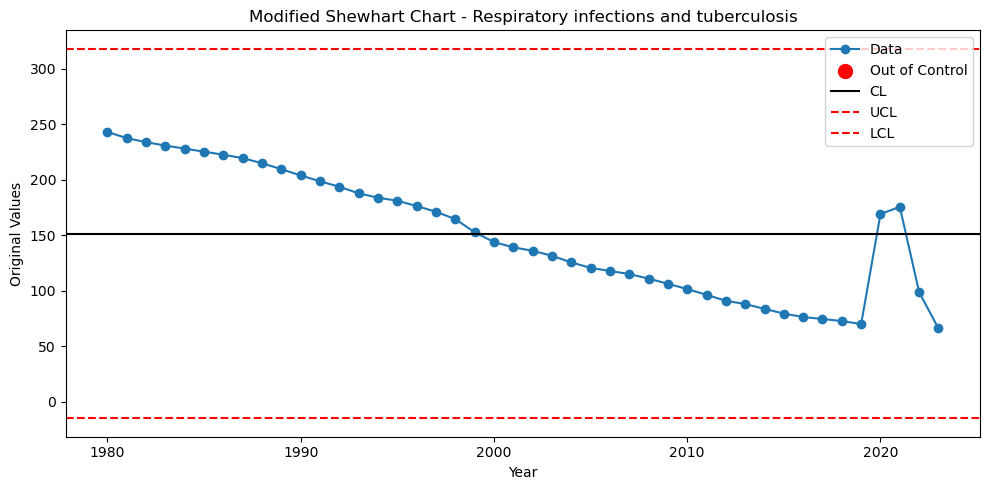


Processing: Cardiovascular diseases
d=0 | ADF p=0.9934, KPSS p=0.0100
d=1 | ADF p=0.0763, KPSS p=0.1000
d=2 | ADF p=0.0373, KPSS p=0.0417
Selected d: 2


C:\Users\kumar\AppData\Local\Temp\ipykernel_23096\4019643203.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(temp, regression='c', nlags="auto")[1]
C:\Users\kumar\AppData\Local\Temp\ipykernel_23096\4019643203.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(temp, regression='c', nlags="auto")[1]
C:\Users\kumar\anaconda3\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\kumar\anaconda3\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dat

Best model: (0, 2, 1)
Estimated autocorrelation (phi): 0.823
Using Modified Shewhart Chart (Raw Data)


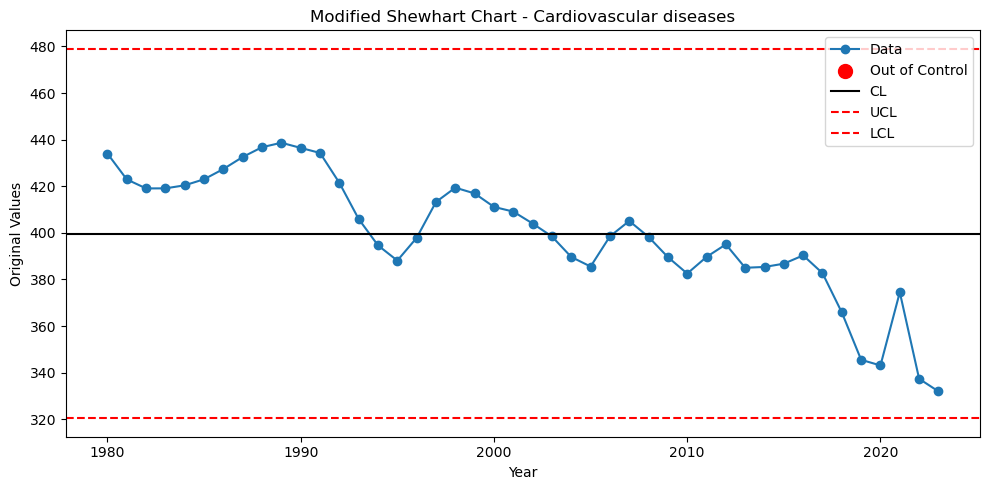


Processing: Enteric infections
d=0 | ADF p=0.6662, KPSS p=0.0100
d=1 | ADF p=0.3045, KPSS p=0.0943
d=2 | ADF p=0.0000, KPSS p=0.1000
Selected d: 2


C:\Users\kumar\AppData\Local\Temp\ipykernel_23096\4019643203.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(temp, regression='c', nlags="auto")[1]
C:\Users\kumar\AppData\Local\Temp\ipykernel_23096\4019643203.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(temp, regression='c', nlags="auto")[1]
C:\Users\kumar\anaconda3\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\kumar\anaconda3\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dat

Best model: (2, 2, 2)
Estimated autocorrelation (phi): 0.945
Using Modified Shewhart Chart (Raw Data)


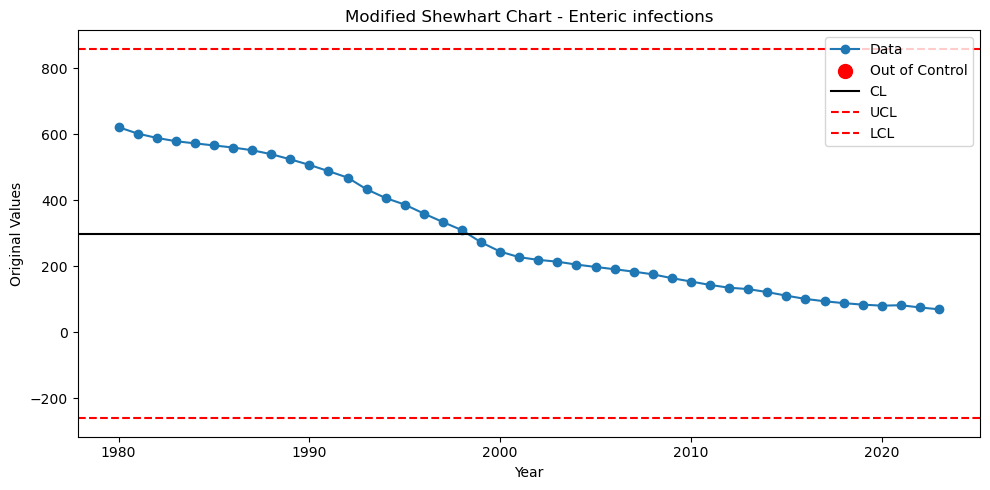

In [3]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, kpss, acf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf


# -------------------------------
# STEP 1: Find differencing order
# -------------------------------
def find_d(ts, max_d=2):
    temp = ts.copy()
    
    for d in range(max_d + 1):
        adf_p = adfuller(temp)[1]
        kpss_p = kpss(temp, regression='c', nlags="auto")[1]
        
        print(f"d={d} | ADF p={adf_p:.4f}, KPSS p={kpss_p:.4f}")
        
        if adf_p < 0.05 and kpss_p > 0.05:
            return d
        
        if d < max_d:
            temp = temp.diff().dropna()
    
    return max_d


# -------------------------------
# LOAD DATA
# -------------------------------
df = pd.read_csv("C:/Users/kumar/Downloads/both_gender.csv")
df = df[df['location_name'] == 'Andhra Pradesh']

diseases = [
    'Respiratory infections and tuberculosis',
    'Cardiovascular diseases',	
    'Enteric infections'
]


# -------------------------------
# MAIN LOOP
# -------------------------------
for disease in diseases:
    
    print("\n" + "="*60)
    print(f"Processing: {disease}")
    
    df_d = df[df['cause_name'] == disease].sort_values('year')
    ts = df_d['val']
    ts.index = df_d['year']
    
    # -------------------------------
    # Find differencing
    # -------------------------------
    d = find_d(ts)
    print("Selected d:", d)
    
    # -------------------------------
    # Model selection
    # -------------------------------
    best_aic = np.inf
    best_model = None
    
    for p, q in itertools.product(range(3), range(3)):
        try:
            model = ARIMA(ts, order=(p, d, q)).fit()
            if model.aic < best_aic:
                best_aic = model.aic
                best_model = model
                best_order = (p, d, q)
        except:
            continue
    
    print("Best model:", best_order)
    
    # -------------------------------
    # Estimate autocorrelation (lag 1)
    # -------------------------------
    phi = acf(ts.dropna(), nlags=1)[1]
    print(f"Estimated autocorrelation (phi): {phi:.3f}")
    
    # -------------------------------
    # CASE 1: POSITIVE CORRELATION
    # Use MODIFIED SHEWHART CHART
    # -------------------------------
    if phi > 0:
        print("Using Modified Shewhart Chart (Raw Data)")
        
        mean = np.mean(ts)
        std = np.std(ts)
        
        ucl = mean + 3 * std
        lcl = mean - 3 * std
        
        values = ts
        out_of_control = (values > ucl) | (values < lcl)
        
        ylabel = "Original Values"
        title = f"Modified Shewhart Chart - {disease}"
    
    # -------------------------------
    # CASE 2: NEGATIVE CORRELATION
    # Use RESIDUAL CONTROL CHART
    # -------------------------------
    else:
        print("Using Residual Control Chart")
        
        residuals = best_model.resid.iloc[2:]
        
        print("\nLjung-Box Test:")
        print(acorr_ljungbox(residuals, lags=[10], return_df=True))
        
        plot_acf(residuals)
        plt.title(f"Residual ACF - {disease}")
        plt.show()
        
        mean = 0  # important (paper)
        std = np.std(residuals)
        
        ucl = 3 * std
        lcl = -3 * std
        
        values = residuals
        out_of_control = (values > ucl) | (values < lcl)
        
        ylabel = "Residuals"
        title = f"Residual Control Chart - {disease}"
    
    # -------------------------------
    # PLOT
    # -------------------------------
    plt.figure(figsize=(10,5))
    
    plt.plot(values.index, values, marker='o', label='Data')
    
    plt.scatter(values.index[out_of_control],
                values[out_of_control],
                color='red',
                s=100,
                label='Out of Control',
                zorder=3)
    
    plt.axhline(mean, color='black', label='CL')
    plt.axhline(ucl, linestyle='--', color='red', label='UCL')
    plt.axhline(lcl, linestyle='--', color='red', label='LCL')
    
    for x, y in zip(values.index[out_of_control], values[out_of_control]):
        plt.text(x, y, str(x), fontsize=8, ha='right')
    
    plt.xlabel("Year")
    plt.ylabel(ylabel)
    plt.title(title)
    
    plt.legend()
    plt.tight_layout()
    plt.show()


Processing: Respiratory infections and tuberculosis
d=0 | ADF p=0.5182, KPSS p=0.0100
d=1 | ADF p=0.0000, KPSS p=0.1000
Selected d: 1


C:\Users\kumar\AppData\Local\Temp\ipykernel_23096\3202912662.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(temp, regression='c', nlags="auto")[1]
C:\Users\kumar\AppData\Local\Temp\ipykernel_23096\3202912662.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(temp, regression='c', nlags="auto")[1]
C:\Users\kumar\anaconda3\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\kumar\anaconda3\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dat

Best model: (2, 1, 0)
Estimated phi: 0.877
Using TRUE Modified Shewhart Chart


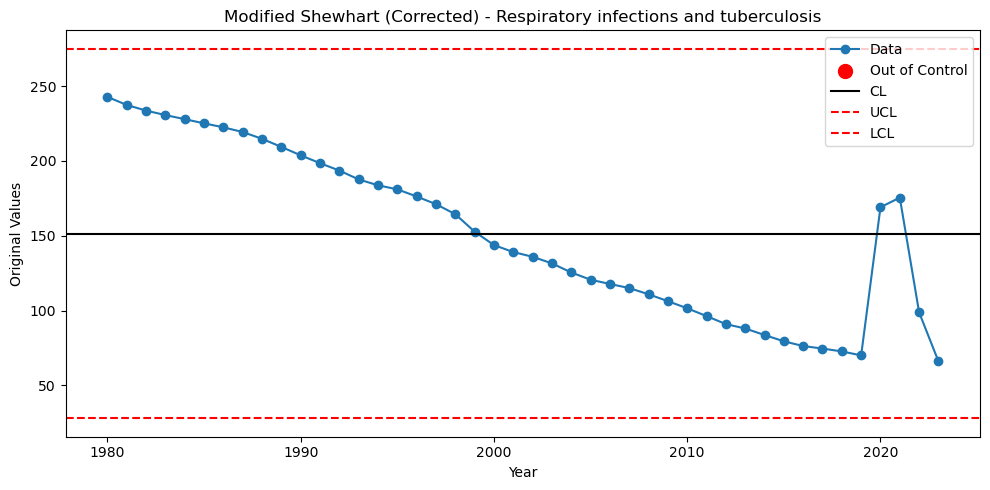


Processing: Cardiovascular diseases
d=0 | ADF p=0.9934, KPSS p=0.0100
d=1 | ADF p=0.0763, KPSS p=0.1000
d=2 | ADF p=0.0373, KPSS p=0.0417
Selected d: 2


C:\Users\kumar\AppData\Local\Temp\ipykernel_23096\3202912662.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(temp, regression='c', nlags="auto")[1]
C:\Users\kumar\AppData\Local\Temp\ipykernel_23096\3202912662.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(temp, regression='c', nlags="auto")[1]
C:\Users\kumar\anaconda3\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\kumar\anaconda3\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dat

Best model: (0, 2, 1)
Estimated phi: 0.823
Using TRUE Modified Shewhart Chart


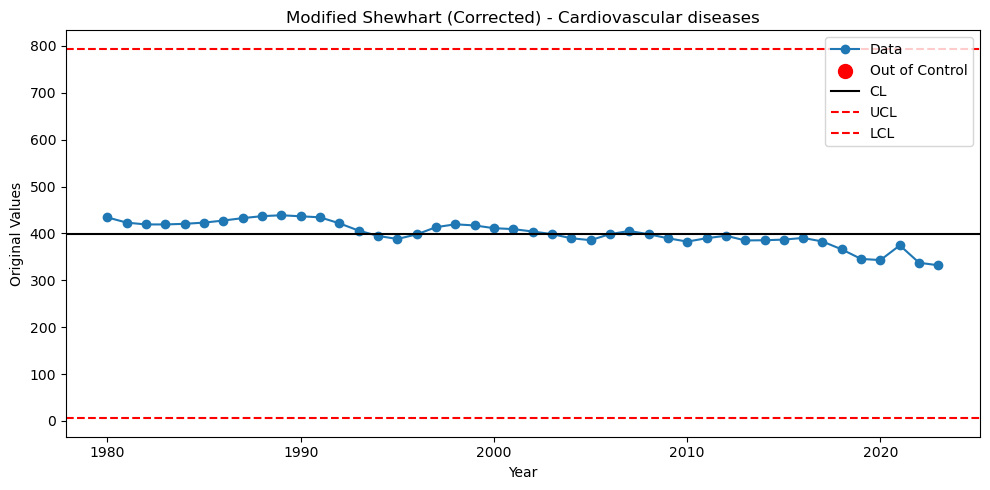


Processing: Enteric infections
d=0 | ADF p=0.6662, KPSS p=0.0100
d=1 | ADF p=0.3045, KPSS p=0.0943
d=2 | ADF p=0.0000, KPSS p=0.1000
Selected d: 2


C:\Users\kumar\AppData\Local\Temp\ipykernel_23096\3202912662.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(temp, regression='c', nlags="auto")[1]
C:\Users\kumar\AppData\Local\Temp\ipykernel_23096\3202912662.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(temp, regression='c', nlags="auto")[1]
C:\Users\kumar\anaconda3\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\kumar\anaconda3\anaconda4\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dat

Best model: (2, 2, 2)
Estimated phi: 0.945
Using TRUE Modified Shewhart Chart


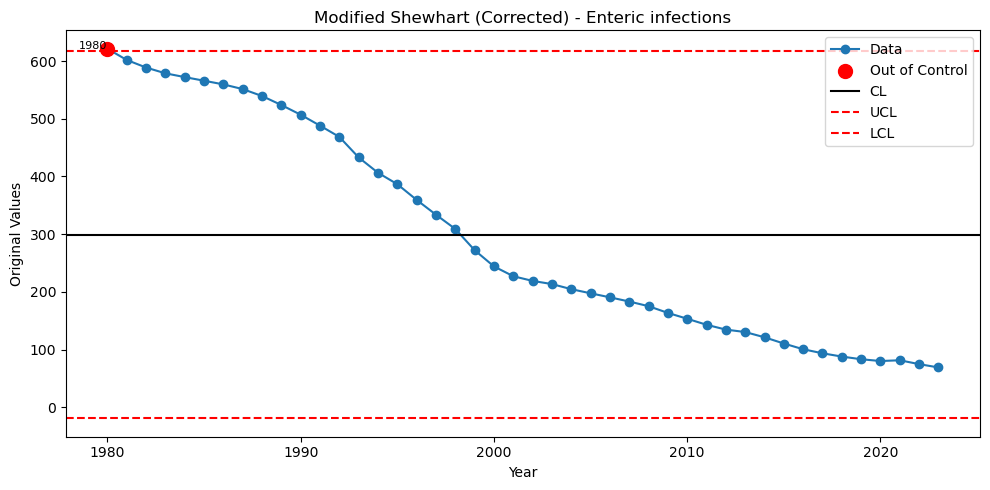

In [4]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, kpss, acf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf


# -------------------------------
# Find differencing order
# -------------------------------
def find_d(ts, max_d=2):
    temp = ts.copy()
    
    for d in range(max_d + 1):
        adf_p = adfuller(temp)[1]
        kpss_p = kpss(temp, regression='c', nlags="auto")[1]
        
        print(f"d={d} | ADF p={adf_p:.4f}, KPSS p={kpss_p:.4f}")
        
        if adf_p < 0.05 and kpss_p > 0.05:
            return d
        
        if d < max_d:
            temp = temp.diff().dropna()
    
    return max_d


# -------------------------------
# Load data
# -------------------------------
df = pd.read_csv("C:/Users/kumar/Downloads/both_gender.csv")
df = df[df['location_name'] == 'Andhra Pradesh']

diseases = [
    'Respiratory infections and tuberculosis',
    'Cardiovascular diseases',	
    'Enteric infections'
]


# -------------------------------
# Main loop
# -------------------------------
for disease in diseases:
    
    print("\n" + "="*60)
    print(f"Processing: {disease}")
    
    df_d = df[df['cause_name'] == disease].sort_values('year')
    ts = df_d['val']
    ts.index = df_d['year']
    
    # Differencing
    d = find_d(ts)
    print("Selected d:", d)
    
    # Model selection
    best_aic = np.inf
    best_model = None
    
    for p, q in itertools.product(range(3), range(3)):
        try:
            model = ARIMA(ts, order=(p, d, q)).fit()
            if model.aic < best_aic:
                best_aic = model.aic
                best_model = model
                best_order = (p, d, q)
        except:
            continue
    
    print("Best model:", best_order)
    
    # Estimate autocorrelation
    phi = acf(ts.dropna(), nlags=1)[1]
    print(f"Estimated phi: {phi:.3f}")
    
    # -------------------------------
    # CASE 1: POSITIVE CORRELATION
    # TRUE MODIFIED SHEWHART
    # -------------------------------
    if phi > 0:
        print("Using TRUE Modified Shewhart Chart")
        
        residuals = best_model.resid
        
        # innovation variance
        sigma_e = np.std(residuals)
        
        # AR coefficient (if exists)
        try:
            phi_model = best_model.arparams[0]
        except:
            phi_model = phi  # fallback
        
        # corrected variance for AR(1)
        if abs(phi_model) < 1:
            std_corrected = sigma_e / np.sqrt(1 - phi_model**2)
        else:
            std_corrected = sigma_e
        
        mean = np.mean(ts)
        
        ucl = mean + 3 * std_corrected
        lcl = mean - 3 * std_corrected
        
        values = ts
        ylabel = "Original Values"
        title = f"Modified Shewhart (Corrected) - {disease}"
    
    # -------------------------------
    # CASE 2: NEGATIVE CORRELATION
    # RESIDUAL CHART
    # -------------------------------
    else:
        print("Using Residual Control Chart")
        
        residuals = best_model.resid.iloc[2:]
        
        print("\nLjung-Box Test:")
        print(acorr_ljungbox(residuals, lags=[10], return_df=True))
        
        plot_acf(residuals)
        plt.title(f"Residual ACF - {disease}")
        plt.show()
        
        std = np.std(residuals)
        
        mean = 0
        ucl = 3 * std
        lcl = -3 * std
        
        values = residuals
        ylabel = "Residuals"
        title = f"Residual Control Chart - {disease}"
    
    # -------------------------------
    # Plot
    # -------------------------------
    out_of_control = (values > ucl) | (values < lcl)
    
    plt.figure(figsize=(10,5))
    
    plt.plot(values.index, values, marker='o', label='Data')
    
    plt.scatter(values.index[out_of_control],
                values[out_of_control],
                color='red',
                s=100,
                label='Out of Control',
                zorder=3)
    
    plt.axhline(mean, color='black', label='CL')
    plt.axhline(ucl, linestyle='--', color='red', label='UCL')
    plt.axhline(lcl, linestyle='--', color='red', label='LCL')
    
    for x, y in zip(values.index[out_of_control], values[out_of_control]):
        plt.text(x, y, str(x), fontsize=8, ha='right')
    
    plt.xlabel("Year")
    plt.ylabel(ylabel)
    plt.title(title)
    
    plt.legend()
    plt.tight_layout()
    plt.show()